In [2]:
import matplotlib.pyplot as plt
from glob import glob
import os
import json
import seaborn as sns
import pandas as pd

In [3]:
stacked = []
for path in glob("./data/*/amplitudes/*json"):
    splitpath = path.split("/")
    basis = splitpath[2]
    name = splitpath[-1].split('_')[2]
    with open(path,'r') as f:
        metrics = json.load(f)
    
    
    gendf = pd.DataFrame.from_dict(metrics['amplitude_generation_times'],orient='index').rename(columns={0:'amplitude_generation_times'})
    metricdf = pd.DataFrame.from_dict(metrics['metrics'],orient='index').rename(columns={0:'metrics'})
    metricdf.loc['t2',metricdf.columns] = 0
    gendf = gendf.rename(index={'Zeroes':'t2_zeroes', 'Random':'t2_rand', 'MP2*':'t2_MP2', "ML":'t2_ML',"Exact":'t2', 'ML_exact':'t2_ML_exact'})

    joined = pd.concat([metricdf,gendf],axis=1)
    joined['molecule'] = metrics['molecule']
    joined['basis'] = metrics['basis']
    
    # gendf.index = metricdf.index
    stacked.append(joined)

stackeddf = pd.concat(stacked).reset_index().rename(columns={'index':'Amplitude'})


In [4]:
stackeddf.head()

,Amplitude,MAE,MSE,MAPE,amplitude_generation_times,molecule,basis
0,t2_zeroes,7.059396e-04,6.236266e-06,1.287753e+00,0.000109,but-1-yne,STO-3G
1,t2_rand,4.992295e+01,3.317223e+03,4.014740e+09,0.000560,but-1-yne,STO-3G
2,t2_MP2,2.138487e-04,6.115696e-07,6.895596e-01,0.000002,but-1-yne,STO-3G
3,t2_ML,7.930121e-05,2.122085e-07,9.495871e-01,0.116638,but-1-yne,STO-3G
4,t2_ML_exact,1.018379e-10,2.993258e-19,1.029554e-06,0.915361,but-1-yne,STO-3G


In [3]:
stackeddf.loc[stackeddf['Amplitude']=='t2_zeroes','MAE'].describe()

count    36.000000
mean      0.000999
std       0.001628
min       0.000054
25%       0.000122
50%       0.000329
75%       0.000882
max       0.006494
Name: MAE, dtype: float64

In [4]:
stackeddf.loc[stackeddf['Amplitude']=='t2_zeroes','MAE'].describe()

count    36.000000
mean      0.000999
std       0.001628
min       0.000054
25%       0.000122
50%       0.000329
75%       0.000882
max       0.006494
Name: MAE, dtype: float64

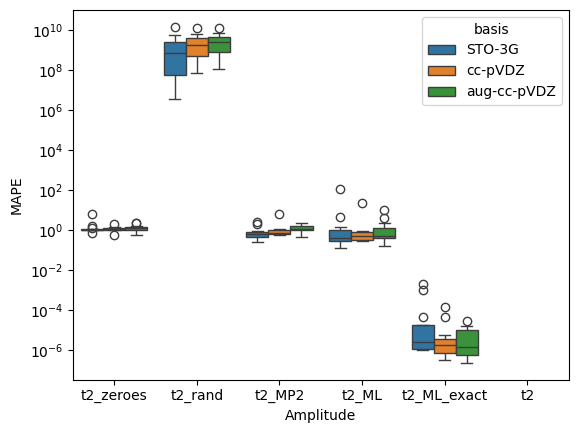

In [5]:
sns.boxplot(stackeddf,x='Amplitude',y='MAPE',hue='basis')
plt.yscale("log")

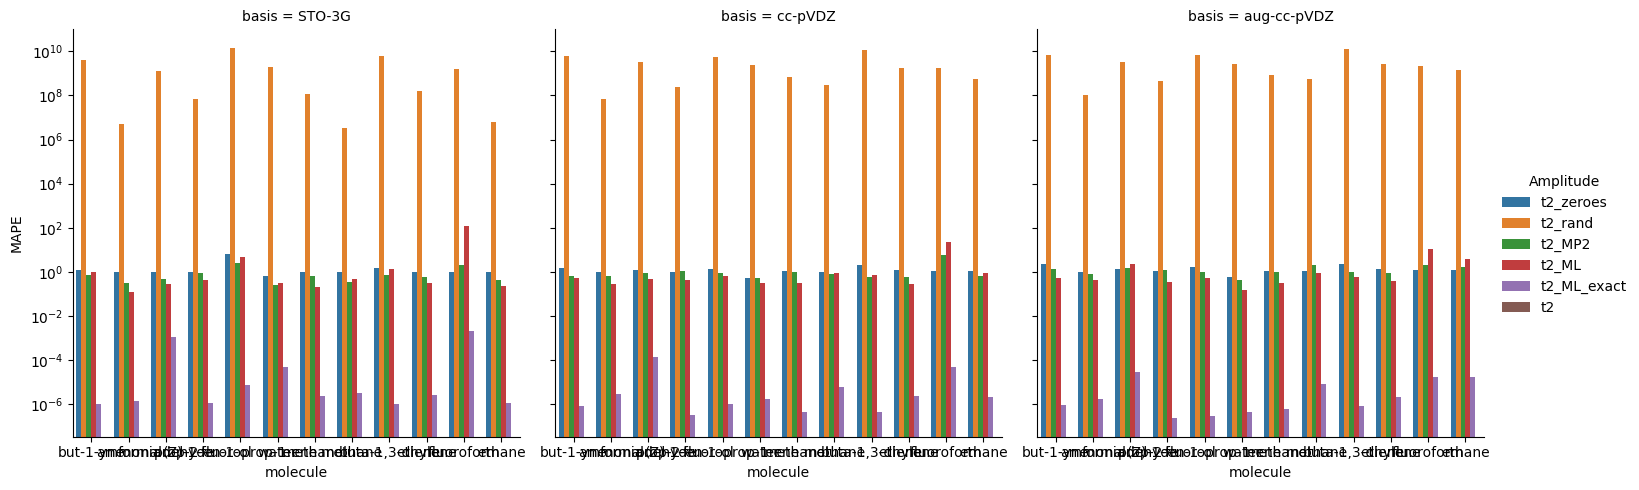

In [6]:
g = sns.catplot(stackeddf,x='molecule',y='MAPE',hue='Amplitude',col='basis',kind='bar')
for ax in g.axes:
    ax[0].set_yscale("log")

In [7]:
# MAPE of the amplitudes vs the energy deviation or energies